<a href="https://colab.research.google.com/github/fajar67878/Clustering_app/blob/main/Analisis_Kualitas_Udara_jakarta_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ispu_dki_all.csv to ispu_dki_all (4).csv


In [ ]:
!pip install xgboost -q

In [ ]:
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost missingno

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

print('✅ Library berhasil di-import!')

✅ Library berhasil di-import!


In [ ]:
df = pd.read_csv('ispu_dki_all.csv')
print(f'Dataset berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom')
df.head()

Dataset berhasil dimuat: 5538 baris, 11 kolom


,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical,categori
0,2010-01-01,DKI1 (Bunderan HI),NaN,60.0000,4.0000,73.0000,27.0000,14.0000,73.0000,CO,SEDANG
1,2010-01-02,DKI1 (Bunderan HI),NaN,32.0000,2.0000,16.0000,33.0000,9.0000,33.0000,O3,BAIK
2,2010-01-03,DKI1 (Bunderan HI),NaN,27.0000,2.0000,19.0000,20.0000,9.0000,27.0000,PM10,BAIK
3,2010-01-04,DKI1 (Bunderan HI),NaN,22.0000,2.0000,16.0000,15.0000,6.0000,22.0000,PM10,BAIK
4,2010-01-05,DKI1 (Bunderan HI),NaN,25.0000,2.0000,17.0000,15.0000,8.0000,25.0000,PM10,BAIK


In [ ]:
print('=== DIMENSI DATASET ===')
print(f'Jumlah baris   : {df.shape[0]:,}')
print(f'Jumlah kolom   : {df.shape[1]}')
df.info()

=== DIMENSI DATASET ===
Jumlah baris   : 5,538
Jumlah kolom   : 11
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5538 entries, 0 to 5537
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tanggal   5538 non-null   object 
 1   stasiun   5537 non-null   object 
 2   pm25      1516 non-null   float64
 3   pm10      5223 non-null   float64
 4   so2       5408 non-null   float64
 5   co        5450 non-null   float64
 6   o3        5434 non-null   float64
 7   no2       5432 non-null   float64
 8   max       5537 non-null   float64
 9   critical  5534 non-null   object 
 10  categori  5538 non-null   object 
dtypes: float64(7), object(4)
memory usage: 476.1+ KB


In [ ]:
print('=== STATISTIK DESKRIPTIF (NUMERIK) ===')
df.describe().T

=== STATISTIK DESKRIPTIF (NUMERIK) ===


,count,mean,std,min,25%,50%,75%,max
pm25,1516.0000,89.7421,26.6160,10.0000,71.0000,90.0000,107.0000,287.0000
pm10,5223.0000,56.4070,20.0110,2.0000,45.0000,57.0000,67.0000,187.0000
so2,5408.0000,22.4362,15.4506,0.0000,10.0000,18.0000,32.0000,112.0000
co,5450.0000,20.4228,11.9662,0.0000,12.0000,18.0000,26.0000,119.0000
o3,5434.0000,77.4658,51.7981,4.0000,36.0000,69.0000,103.0000,314.0000
no2,5432.0000,14.3492,10.0511,1.0000,8.0000,12.0000,18.0000,202.0000
max,5537.0000,97.6258,40.9554,0.0000,70.0000,90.0000,114.0000,314.0000


In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
display(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing (%)', ascending=False))

print(f'Jumlah data duplikat: {df.duplicated().sum()}')

,Missing Count,Missing (%)
pm25,4022,72.6300
pm10,315,5.6900
so2,130,2.3500
no2,106,1.9100
o3,104,1.8800
co,88,1.5900
critical,4,0.0700
stasiun,1,0.0200
max,1,0.0200


Jumlah data duplikat: 0


In [ ]:
df_clean = df.copy()
print(f'Dataset disalin: {df_clean.shape}')

Dataset disalin: (5538, 11)


In [ ]:
# Isi missing kategorikal saja (bukan bagian dari fitur numerik model)
for col in ['stasiun', 'critical']:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# TIDAK ada imputasi untuk pm25, pm10, so2, co, o3, no2
# -> NaN dibiarkan asli (data pengukuran sungguhan), XGBoost menangani otomatis

print('=== MISSING VALUE (TANPA IMPUTASI, DATA ASLI) ===')
print(df_clean.isnull().sum())

=== MISSING VALUE (TANPA IMPUTASI, DATA ASLI) ===
tanggal        0
stasiun        0
pm25        4022
pm10         315
so2          130
co            88
o3           104
no2          106
max            1
critical       0
categori       0
dtype: int64


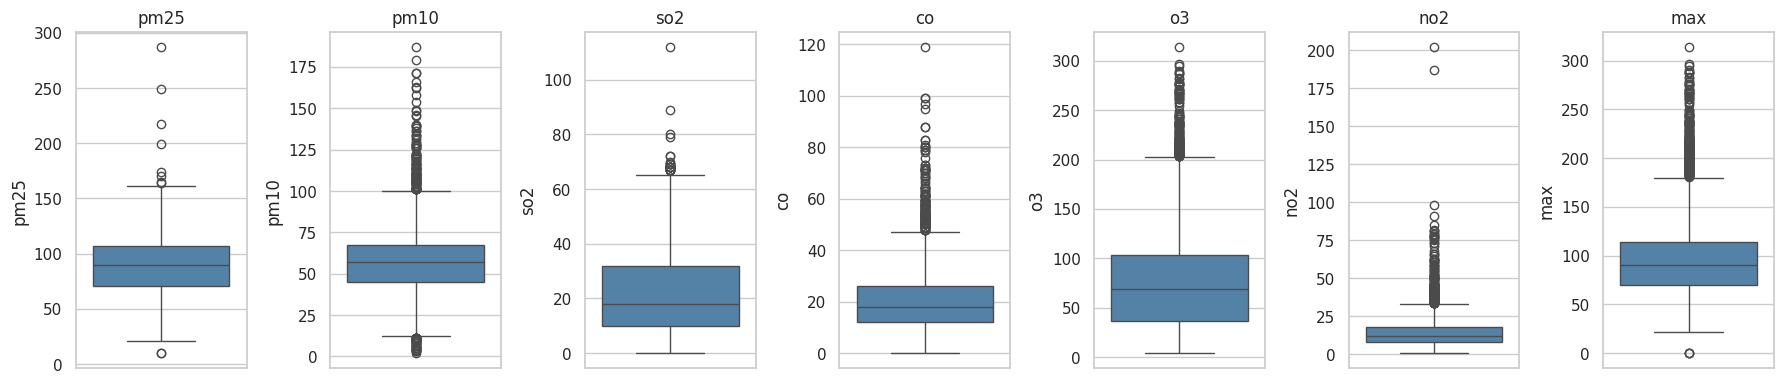

In [ ]:
num_cols = ['pm25', 'pm10', 'so2', 'co', 'o3', 'no2', 'max']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df_clean[col], ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

# XGBoost berbasis pohon -> robust terhadap outlier, tidak perlu capping

In [ ]:
print(f'Sebelum: {df_clean.shape[0]} baris')
df_clean.drop_duplicates(inplace=True)
print(f'Sesudah: {df_clean.shape[0]} baris')

Sebelum: 5538 baris
Sesudah: 5538 baris


In [ ]:
from sklearn.preprocessing import LabelEncoder

le_dict = {}
for col in ['critical', 'categori']:
    le = LabelEncoder()
    df_clean[col + '_encoded'] = le.fit_transform(df_clean[col])
    le_dict[col] = le

df_clean.head()

,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical,categori,critical_encoded,categori_encoded
0,2010-01-01,DKI1 (Bunderan HI),NaN,60.0000,4.0000,73.0000,27.0000,14.0000,73.0000,CO,SEDANG,0,3
1,2010-01-02,DKI1 (Bunderan HI),NaN,32.0000,2.0000,16.0000,33.0000,9.0000,33.0000,O3,BAIK,2,0
2,2010-01-03,DKI1 (Bunderan HI),NaN,27.0000,2.0000,19.0000,20.0000,9.0000,27.0000,PM10,BAIK,3,0
3,2010-01-04,DKI1 (Bunderan HI),NaN,22.0000,2.0000,16.0000,15.0000,6.0000,22.0000,PM10,BAIK,3,0
4,2010-01-05,DKI1 (Bunderan HI),NaN,25.0000,2.0000,17.0000,15.0000,8.0000,25.0000,PM10,BAIK,3,0


In [ ]:
df_clean['tanggal'] = pd.to_datetime(df_clean['tanggal'])
df_clean['tahun'] = df_clean['tanggal'].dt.year
df_clean['bulan'] = df_clean['tanggal'].dt.month

print(f'Shape akhir: {df_clean.shape}')
df_clean.head()

Shape akhir: (5538, 15)


,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical,categori,critical_encoded,categori_encoded,tahun,bulan
0,2010-01-01,DKI1 (Bunderan HI),NaN,60.0000,4.0000,73.0000,27.0000,14.0000,73.0000,CO,SEDANG,0,3,2010,1
1,2010-01-02,DKI1 (Bunderan HI),NaN,32.0000,2.0000,16.0000,33.0000,9.0000,33.0000,O3,BAIK,2,0,2010,1
2,2010-01-03,DKI1 (Bunderan HI),NaN,27.0000,2.0000,19.0000,20.0000,9.0000,27.0000,PM10,BAIK,3,0,2010,1
3,2010-01-04,DKI1 (Bunderan HI),NaN,22.0000,2.0000,16.0000,15.0000,6.0000,22.0000,PM10,BAIK,3,0,2010,1
4,2010-01-05,DKI1 (Bunderan HI),NaN,25.0000,2.0000,17.0000,15.0000,8.0000,25.0000,PM10,BAIK,3,0,2010,1


In [ ]:
from sklearn.model_selection import train_test_split

fitur = ['pm25', 'pm10', 'so2', 'co', 'o3', 'no2', 'tahun', 'bulan']
target = 'max'

df_model = df_clean.dropna(subset=[target])  # baris tanpa label target tetap dibuang

X = df_model[fitur]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set : {X_train.shape[0]} sampel')
print(f'Test set     : {X_test.shape[0]} sampel')
print(X_train.isnull().sum())

Training set : 4429 sampel
Test set     : 1108 sampel
pm25     3222
pm10      258
so2       109
co         72
o3         79
no2        82
tahun       0
bulan       0
dtype: int64


✅ Model XGBoost berhasil dilatih


,Fitur,Importance
4,o3,0.6797
0,pm25,0.1322
6,tahun,0.0688
1,pm10,0.0648
7,bulan,0.0174
5,no2,0.0148
2,so2,0.0138
3,co,0.0085


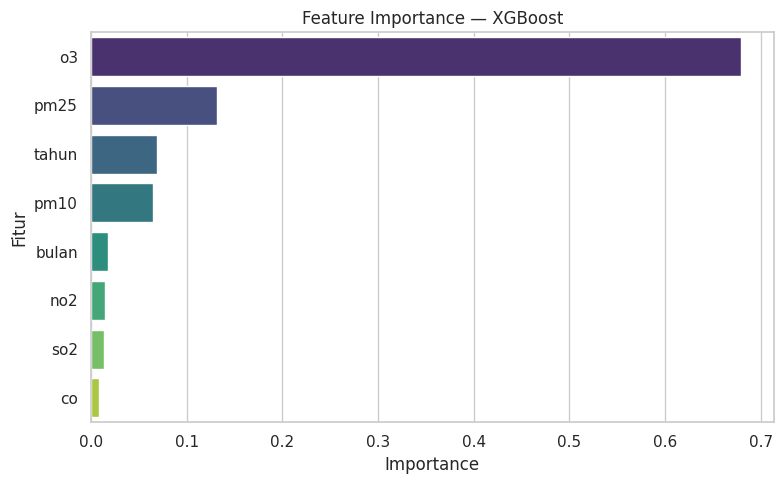

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    missing=np.nan
)

model.fit(X_train, y_train)
print('✅ Model XGBoost berhasil dilatih')

importance = pd.DataFrame({
    'Fitur': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

display(importance)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Fitur', data=importance, palette='viridis')
plt.title('Feature Importance — XGBoost')
plt.tight_layout()
plt.show()

In [ ]:
missing_before = df.isnull().sum()
missing_after = df_clean[['pm25','pm10','so2','co','o3','no2']].isnull().sum()

ringkasan = pd.DataFrame({
    'Sebelum Imputasi': missing_before[['pm25','pm10','so2','co','o3','no2']],
    'Sesudah Imputasi (KNN)': missing_after
})
print('=== RINGKASAN MISSING VALUE: SEBELUM vs SESUDAH ===')
display(ringkasan)

=== RINGKASAN MISSING VALUE: SEBELUM vs SESUDAH ===


,Sebelum Imputasi,Sesudah Imputasi (KNN)
pm25,4022,4022
pm10,315,315
so2,130,130
co,88,88
o3,104,104
no2,106,106


MAE  : 1.2281
MSE  : 4.4082
RMSE : 2.0996
R²   : 0.9975


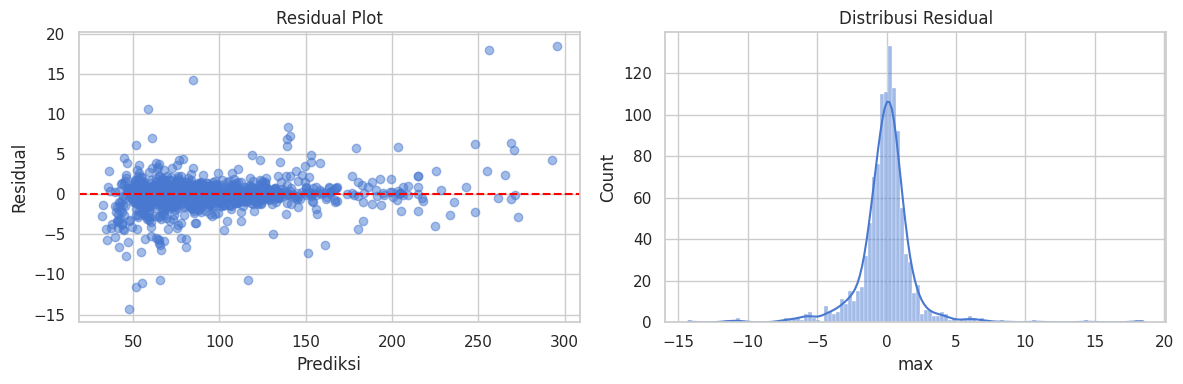

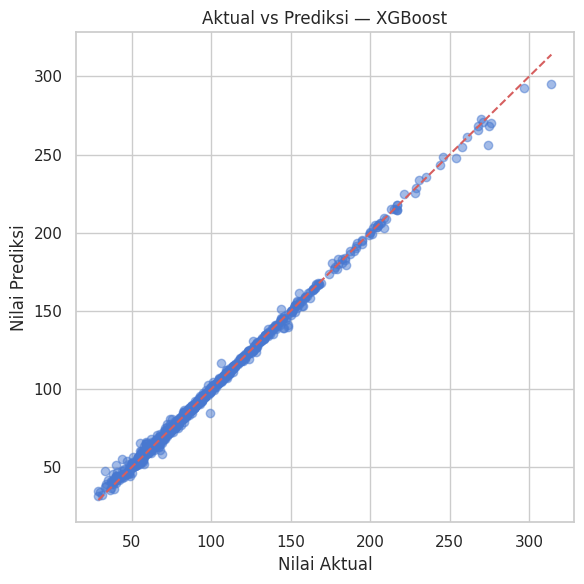

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'MAE  : {mae:.4f}')
print(f'MSE  : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R²   : {r2:.4f}')

residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred, residuals, alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set(xlabel='Prediksi', ylabel='Residual', title='Residual Plot')
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title('Distribusi Residual')
plt.tight_layout(); plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Aktual vs Prediksi — XGBoost')
plt.tight_layout(); plt.show()